In [1]:
# Experiment
# - Info-Gain SoRL
# - 2 Phase switch, Phase I: baseline language modeling, Phase II: SoRL with info-gain target & reward scaling.

import torch
from sorl.gat_sim import GAT, GATConfig, BOS_TOKEN_ID
torch.set_float32_matmul_precision('high')  # Enable TF32 for ~2x speedup
# For fast training, set 'BOS_TOKEN_ID' to 15 in 'sorl/gat_sim.py' 

gat_config = GATConfig(
    vocab_sizes=[BOS_TOKEN_ID+1, 16],  # 16 abstract tokens
    n_layer=4,
    n_head=4,
    n_embd=128,
    device="cuda" if torch.cuda.is_available() else "cpu"
)

model = GAT(gat_config)
# model = model.to("cuda")
# model = torch.compile(model)

# 1. load a small subset of the dataset (checked)
# 2. tokenize & build data loader (checked)
# 3. train with SoRL. 
# 4. visualize abstraciton dynamics (similar to copy-n-paste, but more generally on per-n-gram statistics)

In [31]:
from data.tinystory_local import TinyStoriesDataLoader, collect_rollout_statistics, AbstractionStatistics
from data.tinystory_local import visualize_dynamics
import tiktoken 

# TinyStories Dataset + GPT2 tokenizer
# -------------------------------------
num_stories = 100
max_len = 32
K = max_len // (2**3)

loader = TinyStoriesDataLoader(num_stories=num_stories, max_len=max_len, chunk_size=K, device=model.device)

batch_size = 8
memory_span = 2 * max_len + 2
attn_blocksize = 1792
max_iterations = 2

# ---- stat collection ---
doc_len = max_len  + (max_len - 1) // K # <-- doc len contains abstract tokens
abs_stats = AbstractionStatistics(
    n_doc=num_stories,
    n_abs=doc_len - max_len,
    abs_vocab_size=model.vocab_sizes[1],
    device=model.device
)

# --- tokenizer --- 
enc = tiktoken.get_encoding("gpt2")
eot = enc._special_tokens['<|endoftext|>']

Loading 100 stories from TinyStories train...
Loaded 100 stories, 3200 tokens total, 0.01 MB
Collected 630 unique 4-chunks


In [3]:
# Idea #1. 
# -> Coarse-to-fine abstraction 
# Q1. Is 'coarse' abstraction transferable to 'fine' abstraction? 

In [32]:
# train SoRL with interleaved phase switch (phase I: baseline lm | phase II: SoRL with info-gain target & reward scaling)
from sorl.neo_utils import sorl_evaluate_v2, sorl_search_v8
from sorl.topo import orthogonalize_abs_param
from collections import defaultdict
from sorl.info import SoRLLoss_v8 

# --- orthogonal initialization on abs param --- 
# orthogonalize_abs_param(model, do_wte=True, do_head=True)

loss_fn = SoRLLoss_v8(model.vocab_sizes[1], decay=0.8, target_vocab_util=0.9)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.1)
n = 2
temperature = torch.tensor([0.0, 5.0], device=model.device)
num_steps = 400
alpha_abs = 0.1
alpha_soft_zipf = 1.0
alpha_info_gain = 10.0

record = defaultdict(list)
img_frames = []

for step in range(num_steps): 

    optimizer.zero_grad()

    # Issue -> this guy padds lot of BOS_TOKEN_ID on each data point, I don't want padding
    tokens, doc_ids = loader.get_batch(batch_size)

    with torch.no_grad(): 
        best_data, best_ppt, search_adv, utility_reward = sorl_search_v8(tokens, model, n=n, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=attn_blocksize, temperature=temperature, truncate_seq_len=False)

    # --- compute loss --- 
    base_traj_loss = model.forward(tokens, memory_span, attn_blocksize)[0].mean()
    info_loss, abs_loss, zipf_bigram_loss = loss_fn(best_data, model, base_traj_loss.detach(), utility_reward, memory_span, attn_blocksize)    
    loss = base_traj_loss + alpha_info_gain * info_loss + alpha_abs * abs_loss + alpha_soft_zipf * zipf_bigram_loss

    # --- optimize --- 
    loss.backward() 
    optimizer.step()

    # ---- search info gain ---
    rel_info_gain = ((-info_loss) / base_traj_loss).detach()

    if step % 2 == 0: 
        with torch.no_grad(): 
            temperatures_eval = torch.tensor([0.0, 10.0], device=model.device)

            val_tokens, val_adv, traj_loss, abs_loss, abs_logits, abs_tokens, avg_logit_sim = sorl_evaluate_v2(tokens, model, n=2, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=attn_blocksize, temperature=temperatures_eval,
                                                                     truncate_seq_len=False)

            _, _, zipf_bigram_loss = loss_fn(val_tokens, model, base_traj_loss, utility_reward, memory_span, attn_blocksize)
            abs_stats.update(abs_logits, traj_loss, rel_info_gain, abs_tokens, doc_ids)
            record['vocab_util'].append(abs_stats.vocab_util * 100)
            record['greedy_adv'].append(val_adv.item() * 100)
            record['abs_loss'].append(abs_loss.mean().item())
            record['traj_loss'].append(traj_loss.mean().item())
            record['base_traj_loss'].append(base_traj_loss.item())
            record['bigram_rep_rate'].append(abs_stats.bigram_rep_rate)
            record['kl_soft_zipf'].append(zipf_bigram_loss.item())
            record['rel_search_info_gain'].append(rel_info_gain)

        print(f"\nstep {step} | base traj loss: {base_traj_loss.item():.2f} | cond traj loss: {traj_loss.mean().item():.2f} | rel search info gain: {rel_info_gain * 100:.2f}% | greedy adv: {val_adv.item() * 100:.2f}% | vocab util: {abs_stats.vocab_util * 100:.2f}%  | avg logit sim: {avg_logit_sim:.2f} |  bigram-zipf kl: {zipf_bigram_loss.item():.2f} | bigram rep rate: {abs_stats.bigram_rep_rate:.2f} | rel info gain (search): {rel_info_gain:.2f}")
        
        img = visualize_dynamics(abs_stats, loader, model, enc, K, step)
        img_frames.append(img)
        # break


step 0 | base traj loss: 0.31 | cond traj loss: 0.62 | rel search info gain: -266.97% | greedy adv: -18.49% | vocab util: 43.75%  | avg logit sim: 0.38 |  bigram-zipf kl: 61.00 | bigram rep rate: 0.94 | rel info gain (search): -2.67

step 2 | base traj loss: 0.28 | cond traj loss: 0.64 | rel search info gain: -248.80% | greedy adv: 8.68% | vocab util: 43.75%  | avg logit sim: 0.50 |  bigram-zipf kl: 29.95 | bigram rep rate: 0.87 | rel info gain (search): -2.49

step 4 | base traj loss: 0.40 | cond traj loss: 0.62 | rel search info gain: -125.98% | greedy adv: 11.28% | vocab util: 50.00%  | avg logit sim: 0.53 |  bigram-zipf kl: 15.08 | bigram rep rate: 0.81 | rel info gain (search): -1.26

step 6 | base traj loss: 0.33 | cond traj loss: 0.78 | rel search info gain: -213.17% | greedy adv: 11.74% | vocab util: 50.00%  | avg logit sim: 0.54 |  bigram-zipf kl: 8.07 | bigram rep rate: 0.76 | rel info gain (search): -2.13

step 8 | base traj loss: 0.39 | cond traj loss: 0.53 | rel search in

In [ ]:
# Exp 1. K=16 | 400 steps | util reward | 
#    Initial info gain around -6%, then vocab collapse and recoverse, info gain neg increases to positive in step 300
# -- base traj loss:  0.83 | cond traj loss:  0.70 | greedy adv:  3% | info gain:  12% | vocab util: 25%

# Exp 2. Continu from Exp 1's checkpoint, K=8 | 400 steps | util reward | 
#    Initial info gain around -20%, then increase rapidly to >0% at step 60, suggesting 'transferability' of coarse-to-fine curriculum
#    Greedy adv is 3% from the beginning then increase, vocab util generally increase from 25% 
# -- base traj loss:  0.29 | cond traj loss:  0.18 | greedy adv:  10% | info gain:  33% | vocab util: 56%

# Exp 3. Continue from Exp 2's checkpoint, K=4 | 400 steps | util reward | 
#    Initial info gain -200%, hits positive values first at step 30, then steadily goes >10% at step 60 (rapid transfer)
#    Greedy adv starts at -18% but goes steadily to >5% at the second step then to >15% at step 50 onwards
#    vocabulary starts at 40% then quickly expands to 32% at step 22 then slowly goes up (never contract)
#    so, the contraction phase is no longer present in K-curriculum / coarse-to-fine transfer 
# -- base traj loss:  0.18 | cond traj loss:  0.12 | greedy adv:  29% | info gain:  18% | vocab util: 81%

(0.044445906, 0.9637626608212789, 0.8861373821894328)

In [34]:
from sorl.forget import compute_abs_stats

n = 5
temperature = torch.tensor([0.0] + [5.0] * (n - 1))

# ---- statistics on info gain reward ---
i = 0
batch_size = 16
ig = []
base_traj_loss = []
cond_traj_loss = []
greedy_adv = []

while i < len(loader.stories): 
    batch_indices = torch.arange(i, min(i + batch_size, len(loader.stories)))
    loader.get_specific(batch_indices) 
    i += batch_size
    tokens, doc_ids = loader.get_specific(batch_indices) 
    traj_loss, abs_logits, abs_tokens, doc_rel_info_gain, rel_info_gain, g_adv, base_ppt = compute_abs_stats(tokens, model, n=n, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=attn_blocksize, temperature=temperature,
                                                                                        truncate_seq_len=False)
    # abs_stats.update(abs_logits, traj_loss, doc_rel_info_gain, abs_tokens, doc_ids)
    ig.append(rel_info_gain)
    cond_traj_loss.append(traj_loss.mean().item())
    base_traj_loss.append(base_ppt.mean().item())
    greedy_adv.append(g_adv.mean().item())
    
print("base traj loss: ", torch.tensor(base_traj_loss).mean().item())
print("cond traj loss: ", torch.tensor(cond_traj_loss).mean().item())
print("greedy adv: ", torch.tensor(greedy_adv).mean().item())
print("info gain: ", torch.tensor(ig).mean().item())

base traj loss:  0.1812886893749237
cond traj loss:  0.12221241742372513
greedy adv:  0.2926194965839386
info gain:  0.184419646859169


In [7]:
# Hypothesis #1. 
# - if SoRL does have a 'schema effect', then the more organized it gets (later ckpt) will have 
#   (1). better learning efficiency
#                            (for this, we might need to use some 'new' stories data point)
#   (2). lesser interference (% of closeness->interference correlation should be lesser) 
#                            (% of closeness->alignment correlation should be higher)

# Question #1. 
# Does SoRL has advantage over baseline in info gain and continual learning? 

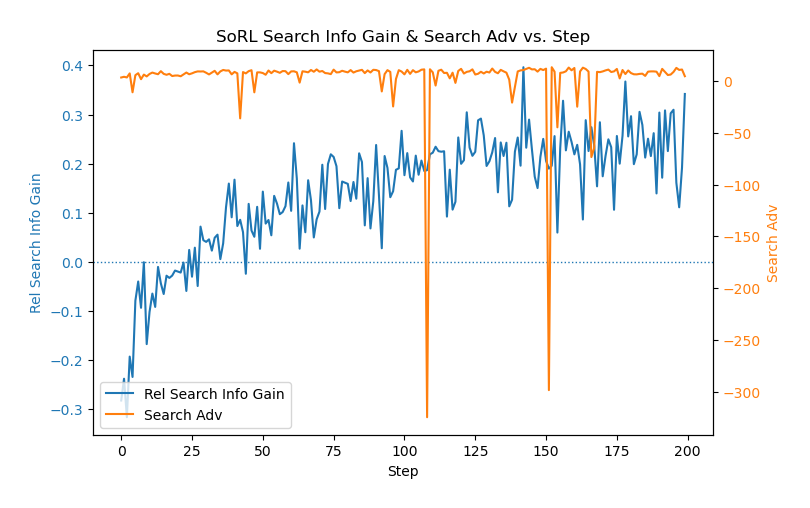

In [25]:
from sorl.forget import plot_rel_info_gain_vs_step

plot_rel_info_gain_vs_step(record)

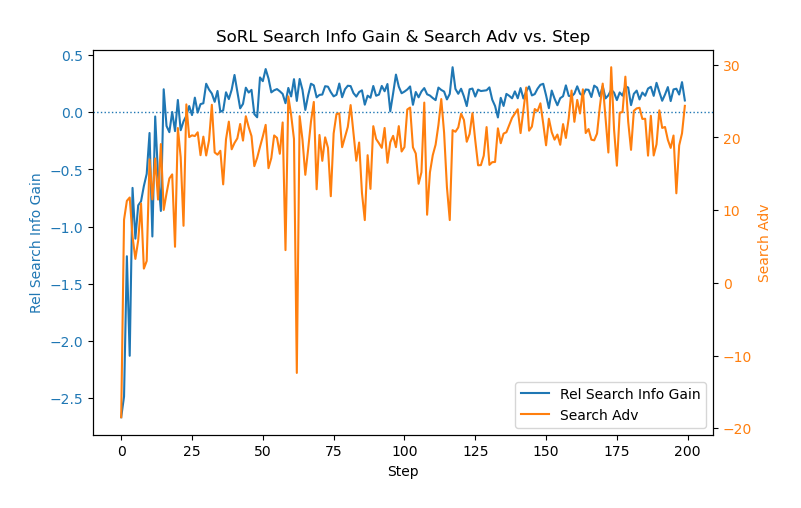

In [35]:
plot_rel_info_gain_vs_step(record)

In [33]:
if len(img_frames) > 0:
    img_frames[0].save(
        'tinystories_dynamics (SoRL + coarse-to-fine K transfer).gif',
        save_all=True,
        append_images=img_frames[1:],
        duration=400,  # milliseconds per frame
        loop=0  # 0 = infinite loop
    )
    print(f"Saved GIF with {len(img_frames)} frames")

Saved GIF with 200 frames
